<a href="https://colab.research.google.com/github/ompattanayak2000/Time-Series-Model/blob/main/Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf

df = yf.download(
    "INFY.NS",
    start="2010-01-01",
    end="2026-01-01"
)

/tmp/ipykernel_1963/3967060481.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


In [ ]:
df.shape


(3949, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3949 entries, 2010-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, INFY.NS)   3949 non-null   float64
 1   (High, INFY.NS)    3949 non-null   float64
 2   (Low, INFY.NS)     3949 non-null   float64
 3   (Open, INFY.NS)    3949 non-null   float64
 4   (Volume, INFY.NS)  3949 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 185.1 KB


In [ ]:
df.head(5)

Price,Close,High,Low,Open,Volume,MA20,MA50
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS,,
Date,,,,,,,
2010-01-04,222.178543,223.658251,220.707327,221.957428,4069264,NaN,NaN
2010-01-05,222.922638,223.717760,221.115513,222.807824,6895528,NaN,NaN
2010-01-06,219.669861,228.165466,218.989531,228.165466,6817288,NaN,NaN
2010-01-07,214.733200,219.967488,214.150660,219.967488,10892600,NaN,NaN
2010-01-08,209.558350,214.584289,209.031099,214.218608,12649312,NaN,NaN


In [ ]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
count,3949.000000,3949.000000,3949.000000,3949.000000,3.949000e+03
mean,733.233600,740.532413,725.905080,733.307132,8.457694e+06
std,524.906250,529.634654,520.116612,524.990365,7.334921e+06
min,189.057983,192.636527,183.427507,190.931274,0.000000e+00
25%,297.987122,301.147015,295.077808,298.522276,5.214378e+06
50%,459.860199,463.609876,454.798075,459.277929,6.936588e+06
75%,1306.255127,1319.223537,1293.470489,1306.567868,9.457072e+06
max,1942.221191,1948.777171,1920.756459,1938.093361,1.663204e+08


In [ ]:
df.isnull().sum()

,,0
Price,Ticker,
Close,INFY.NS,0
High,INFY.NS,0
Low,INFY.NS,0
Open,INFY.NS,0
Volume,INFY.NS,0


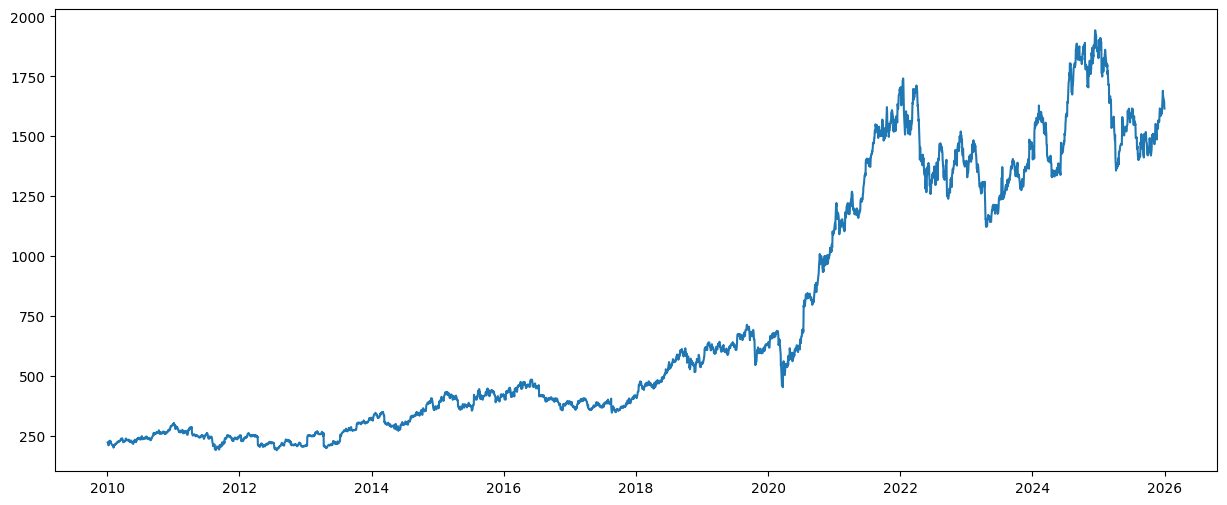

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))

plt.plot(df['Close'])

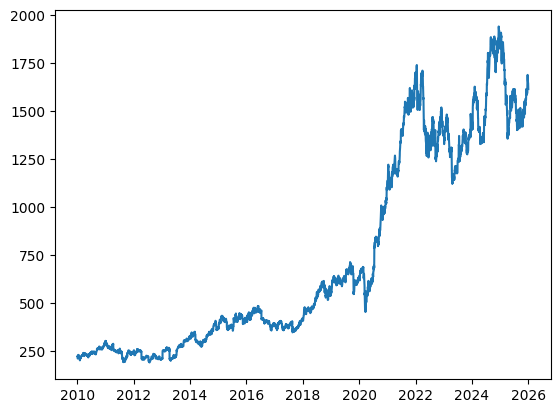

In [ ]:
df['MA20']=df['Close'].rolling(20).mean()

df['MA50']=df['Close'].rolling(50).mean()
plt.plot(df['Close'])
plt.plot(df['MA20'])
plt.plot(df['MA50'])

Dataset Shape: (3949, 1)
Train: (3889, 1)
Test : (60, 1)

RMSE COMPARISON
                   Model        RMSE
0  Exponential Smoothing  123.356945
1                  ARIMA  134.182853
2                Prophet  174.860519

Best Model: Exponential Smoothing

NEXT 5 DAY FORECAST
           Date  Predicted_Close
3949 2026-01-01      1615.754558
3950 2026-01-02      1616.109091
3951 2026-01-05      1616.463624
3952 2026-01-06      1616.818158
3953 2026-01-07      1617.172691


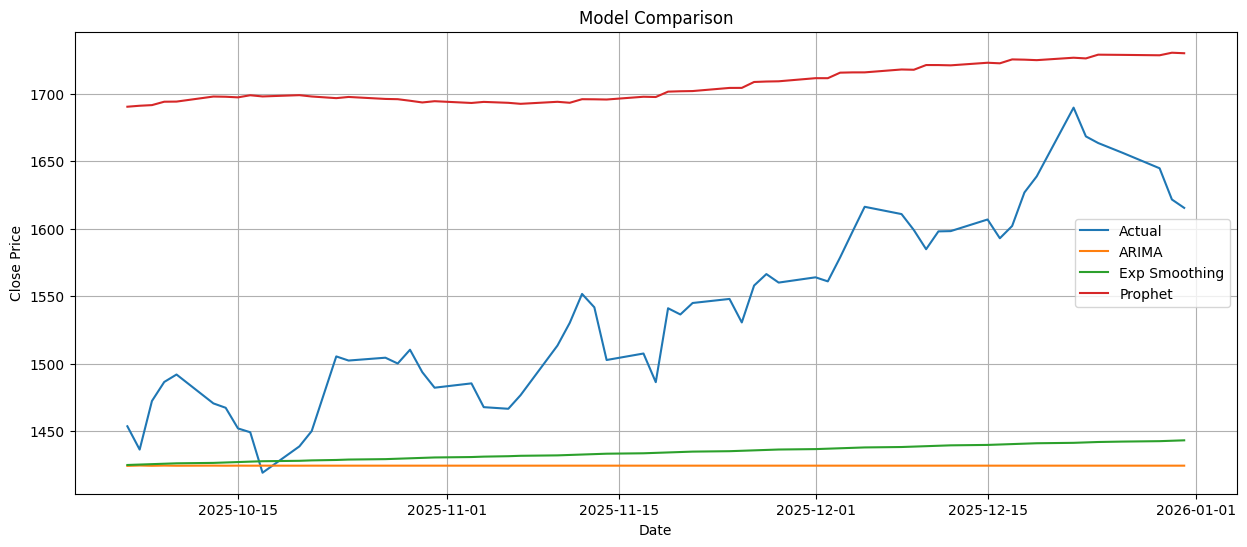

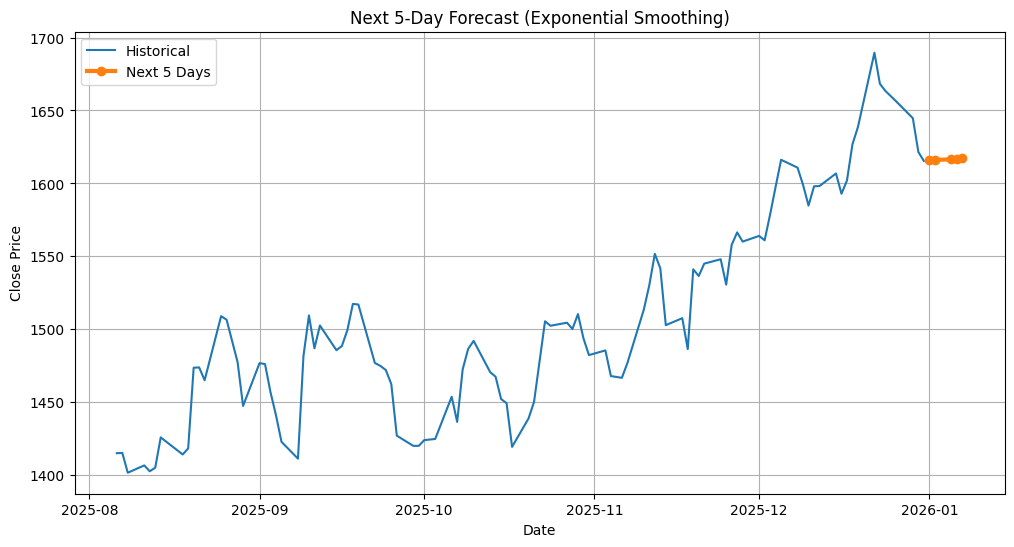

In [ ]:
# ==========================================================
# INFOSYS STOCK FORECASTING
# ARIMA vs Exponential Smoothing vs Prophet
# ==========================================================

# pip install yfinance prophet

import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import numpy as np

from math import sqrt
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

import matplotlib.pyplot as plt

# ==========================================================
# DOWNLOAD DATA
# ==========================================================

df = yf.download(
    "INFY.NS",
    start="2010-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

# Handle MultiIndex columns from yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[['Close']].copy()
df.dropna(inplace=True)

print("Dataset Shape:", df.shape)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

test_size = 60

train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

print("Train:", train.shape)
print("Test :", test.shape)

# ==========================================================
# ARIMA
# ==========================================================

arima = ARIMA(
    train['Close'],
    order=(1,1,1)
)

arima_fit = arima.fit()

arima_pred = arima_fit.forecast(
    steps=len(test)
)

arima_rmse = sqrt(
    mean_squared_error(
        test['Close'],
        arima_pred
    )
)

# ==========================================================
# EXPONENTIAL SMOOTHING
# ==========================================================

es = ExponentialSmoothing(
    train['Close'],
    trend='add',
    seasonal=None
)

es_fit = es.fit()

es_pred = es_fit.forecast(
    len(test)
)

es_rmse = sqrt(
    mean_squared_error(
        test['Close'],
        es_pred
    )
)

# ==========================================================
# PROPHET
# ==========================================================

prophet_train = train.reset_index()

# Keep only Date and Close
prophet_train = prophet_train[['Date', 'Close']]

prophet_train.columns = ['ds', 'y']

prophet_train['ds'] = pd.to_datetime(
    prophet_train['ds']
)

prophet_train['y'] = pd.to_numeric(
    prophet_train['y'],
    errors='coerce'
)

prophet_train.dropna(inplace=True)

prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet.fit(prophet_train)

future = prophet.make_future_dataframe(
    periods=len(test),
    freq='B'
)

forecast = prophet.predict(future)

prophet_pred = forecast['yhat'].tail(
    len(test)
).values

prophet_rmse = sqrt(
    mean_squared_error(
        test['Close'],
        prophet_pred
    )
)

# ==========================================================
# RMSE COMPARISON
# ==========================================================

rmse_df = pd.DataFrame({
    'Model': [
        'ARIMA',
        'Exponential Smoothing',
        'Prophet'
    ],
    'RMSE': [
        arima_rmse,
        es_rmse,
        prophet_rmse
    ]
})

rmse_df = rmse_df.sort_values(
    'RMSE'
).reset_index(drop=True)

print("\nRMSE COMPARISON")
print(rmse_df)

best_model = rmse_df.iloc[0]['Model']

print("\nBest Model:", best_model)

# ==========================================================
# RETRAIN BEST MODEL ON FULL DATA
# ==========================================================

series = df['Close']

if best_model == 'ARIMA':

    model = ARIMA(
        series,
        order=(5,1,0)
    ).fit()

    next5 = model.forecast(5)

elif best_model == 'Exponential Smoothing':

    model = ExponentialSmoothing(
        series,
        trend='add',
        seasonal=None
    ).fit()

    next5 = model.forecast(5)

else:

    prophet_full = df.reset_index()

    prophet_full = prophet_full[
        ['Date', 'Close']
    ]

    prophet_full.columns = [
        'ds',
        'y'
    ]

    prophet_full['ds'] = pd.to_datetime(
        prophet_full['ds']
    )

    prophet_full['y'] = pd.to_numeric(
        prophet_full['y'],
        errors='coerce'
    )

    prophet_full.dropna(inplace=True)

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )

    model.fit(prophet_full)

    future5 = model.make_future_dataframe(
        periods=5,
        freq='B'
    )

    forecast5 = model.predict(
        future5
    )

    next5 = forecast5[
        'yhat'
    ].tail(5).values

# ==========================================================
# NEXT 5 DAY FORECAST
# ==========================================================

future_dates = pd.bdate_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=5
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Close': next5
})

print("\nNEXT 5 DAY FORECAST")
print(forecast_df)

# ==========================================================
# TEST SET COMPARISON PLOT
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test['Close'],
    label='Actual'
)

plt.plot(
    test.index,
    arima_pred,
    label='ARIMA'
)

plt.plot(
    test.index,
    es_pred,
    label='Exp Smoothing'
)

plt.plot(
    test.index,
    prophet_pred,
    label='Prophet'
)

plt.title(
    'Model Comparison'
)

plt.xlabel('Date')
plt.ylabel('Close Price')

plt.legend()
plt.grid(True)

plt.show()

# ==========================================================
# FUTURE FORECAST PLOT
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(
    df.tail(100).index,
    df.tail(100)['Close'],
    label='Historical'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Predicted_Close'],
    marker='o',
    linewidth=3,
    label='Next 5 Days'
)

plt.title(
    f'Next 5-Day Forecast ({best_model})'
)

plt.xlabel('Date')
plt.ylabel('Close Price')

plt.legend()
plt.grid(True)

plt.show()